# AI Modified Workflow

For this workflow we use the following prompt to modify the `scale_model_size.py` notebook:

I would like to log more data about the environment I produce these runs in. Augment the workflow to gather data that would be useful for reproducing it.

---

On my first try prompting it, Copilot ended up just hanging while trying to inspect the current workflow. I was able to interrupt it and get it to succeed by prompting it again.

Starting over, it applied its changes to the `workflows.py` module, which is the sensible place to make them.

Since I don't want to actually modify this module, I manually copied it over into a new file `workflows_new.py` and updated the notebook to import that.  Just to maintain something to compare against I also copied over the workflows module and put it in a file called `workflows_old.py`.  You can diff between the two to see the edits copilot made.

If I run this notebook and look at the generated log this is now inserted (the ####s is text I manually redacted):

```
Environment snapshot written to ##################/experiment/scale_model_size/environment_snapshot.json
Host: ############
Platform: #############
```

It's interesting that it chose to put the environment data into a .JSON file.  I think I might prefer to have it embedded in a more human-readable format directly in the log, but without me having specified that in the prompt I think it's a fair decision to have made.

I tried running this workflow and copied the `environment_snapshot.json` file into this directory.  I manually redacted references to the hostname or other information that could potentially sensitive but looking at it you can get the idea.

Some thoughts on the contents of this file:

  - I thought the command checks section was clever. Really we would want to log version info for any command that exists outside the container and what copilot came up with looks like it covers it.

  - One thing it did was run a bunch of git commands in the experiments directory.  There's no real reason to do this since this isn't held a git repos.  This seems like it would be a useful thing to log so I'm not bothered that Copilot made the assumption.

  - The enviornment metadata has a section about environment variables but doesn't actually log any. Looking at the generated code it looks like its trying to capture variables that start with "SLURM_", "APPTAINER_", etc.
  I like the idea of trying to capture relevant variables, but I'm not sure there are any and really we're trying to do everything in a containerized envrionment so it shouldn't matter anyway. Nevertheless, it might be good for there to be some user-exposed API to let them specify what variables are relevant as that could be workflow specific.

  - Realistically I think I'd want to put more thought into what should and shouldn't be logged. But I think the infrastructure copilot set up for this looks quite useful.

It also added the following text to the log file each time before it ran a trial: 

```
SST image metadata: {"exists": true, "mtime": "2026-04-28T12:04:41-0500", "path": "##############/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-master-latest.sif", "size_bytes": 533110784}
```

Some thoughts:

- I think it would be good to include a hash of the `.sif` file as well.

- I'm invoking this same image multiple times and the data isn't going to change between runs.  For this workflow I think it'd make more sense to log it just once upon startup.

And some thoughts on the implementation:

- Overall I thought the code it wrote was pretty clean. Although because of Python's dynamically typed nature, I think it could benefit from some more documentation about return values.

- Copilot create a `_run_cmd_capture` function to wrap around `subprocess.run`, do some extra checks, etc.  This is a pretty useful function and I have a non capturing version named `run_cmd`.
My version of `run_cmd` takes in arguments as a string I parse apart using `shlex.split`, their version gets passed in a list of arguments.  I can't say that one approach is necessarily better than the other but it would be good for both versions to be consistent with one another.

- I thought it was clever that rather than trying to make a new log file it just appended it to the existing command log that I have.  I have a function called `log()` in the module to add data and it called it.

---
---
---

# Configuration

## Import workflows module

In [ ]:
# NOTE: Since copilot modified the workflows module I copied it into this new
# module and update the notebook to import it.
from workflows_new import *

HELLO FROM USER WORKFLOWS FILE!


In [ ]:
# ---------------------------------------------------------------------------------------------------------------------
# !!! DO NOT MODIFY THE CODE BELOW   !!!
# !!!  (Modify in the next section)  !!!
# ---------------------------------------------------------------------------------------------------------------------

# So that can you can maintain the defaults, we suggest you don't directly edit
# the parameters inline here but rather overwite values at the bottom of this
# cell.

# We'll store our containers and benchmark results under the specified directory
# (it will be created if it doesn't already exist).
import os
if 'user_customExperimentsDir' in globals():
    baseDir = f'{user_customExperimentsDir}/scale_model_size'
else:
    baseDir=f'{os.getenv("HOME")}/workflows/scale_model_size'

# Run using an SST in the specified container. To find containers to use see the
# container factory at https://github.com/hpc-ai-adv-dev/sst-container-factory
# Prebuild containers are available at https://github.com/orgs/hpc-ai-adv-dev/packages
container_url  = 'ghcr.io/hpc-ai-adv-dev/sst-core:master-latest'
container_name = None # DO NOT MODIFY THIS LINE: Variable will be assigned after we download the container
                      # We include it here to document what global variables are available throughout the
                      # notebook.

# The benchmark will be cloned from the specified repository. We assume the
# benchmark itself is in the 'benchmarkPath' directory within the repos.  We
# assume building the benchmark is a matter of running 'make' in that directoy.
benchmarkRepos='https://github.com/hpc-ai-adv-dev/sst-benchmarks.git'
benchmarkPath='phold'

# Run the benchmark on a single node, increasing the numbers of components with each trial
num_comps_per_trial  = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]

# This command will be run prior to launching a job. The command will be run
# from within the benchmark directory and execution occurs within the worklaunch
# loop so it may be parameterized by the trial parameters if needed.
prestart_cmd_template = ''

# Indicates what arguments should be passed to sst and the benchmark each run 
# Note: {width} and {height} will be replaced with the appropriate values for
# each run, based on the number of nodes and components per node
sst_args_template   = '--print-timing-info=3 --parallel-load=SINGLE ./phold_dist.py'
bmark_args_template = '--width {width} --height {height}'

# Additional arguments to pass when launching jobs with srun. For example the
# partition name or --qos=high for higher priority in the queue.
additional_srun_args = ''

# Several of the setup steps will avoid rerunning if they have previously been run. Append to this
# list to indicate when you want to force a step to be reproduced.
#
# VALID VALUES ARE:
#   'ALL'     
#   'DOWNLOAD_CONTAINERS' 
#   'DOWNLOAD_BENCHMARKS' 
#   'BUILD_BENCHMARKS'      Note: we always rerun make, if this is set we will also run 'make clean' before rebuilding
force = []

# ---------------------------------------------------------------------------------------------------------------------
# Overwite parameters below this line to customize the workflow: 
# ---------------------------------------------------------------------------------------------------------------------


[1000, 2000, 3000, 4000, 5000]


## Environment

In [7]:
set_workflow_log(f'{baseDir}/workflow.log')
run_cmd(f'e4s-cl profile edit --add-files {baseDir}')

> e4s-cl profile edit --add-files /lus/bnchlu1/flash/stonea/experiment/scale_model_size


File /lus/bnchlu1/flash/stonea/experiment/scale_model_size already in profile's files


## Download containers

In [8]:
_force = 'ALL' in force or 'DOWNLOAD_CONTAINERS' in force

container_name = download_custom_container(container_url, force=_force)

Container hpc-ai-adv-dev-sst-core-master-latest.sif already exists, skipping download.


## Download benchmarks

In [9]:
_force = 'ALL' in force or 'DOWNLOAD_BENCHMARKS' in force

if not os.path.exists(f'benchmarks') or _force:
    run_cmd(f"git clone {benchmarkRepos} benchmarks")
    run_cmd(f"e4s-cl profile edit --add-files {baseDir}/benchmarks/{benchmarkPath}")
else:
    print(f"Benchmarks from {benchmarkRepos} have already been downloaded, skipping download.")

Benchmarks from https://github.com/hpc-ai-adv-dev/sst-benchmarks.git have already been downloaded, skipping download.


## Build benchmarks 

In [10]:
_force = 'ALL' in force or 'BUILD_BENCHMARKS' in force

cd(f"{baseDir}/benchmarks/{benchmarkPath}")
run_cmd('touch sstsimulator.conf')
_cmd = 'make' if not _force else 'make clean; make'
run_in_container(_cmd,
    f'{baseDir}/{container_name}',
    additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')
cd(baseDir)

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold:/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold', '--pwd', '/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold', '--bind', 'sstsimulator.conf:/home/users/stonea/.sst/sstsimulator.conf', '/lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-master-latest.sif', 'bash', '-lc', 'make']
sst-register phold phold_LIBDIR=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold


# Run

## Start jobs

In [11]:
import math, shutil, os

runDisplay = SafeDisplay(display_handle = display('', display_id="run_disp"))

# Setup directory to store results in
run_dir = f'{baseDir}/runs/'
if os.path.exists(run_dir):
    shutil.rmtree(run_dir)
os.makedirs(run_dir, exist_ok=True)

cd(f"{baseDir}/benchmarks/{benchmarkPath}")

# Deploy jobs
for approx_size in num_comps_per_trial:
    width  = int(math.sqrt(approx_size))
    height = width
    size = width*height

    if prestart_cmd_template is not None and prestart_cmd_template != '':
        run_cmd(prestart_cmd_template.format(width=width, height=height, size=size))

    full_sst_args_template = f'{sst_args_template} -- {bmark_args_template}'
    sst_args = full_sst_args_template.format(width=width, height=height, size=size)

    launch_and_log_sst(
        image        = f'{baseDir}/{container_name}',
        srun_args    = f'-N 1 --job-name={benchmarkPath.lower()}_{size} {additional_srun_args}',
        sst_args     = sst_args,
        log_file     = f'{run_dir}/size_{size}',
        config_path  = f'{baseDir}/benchmarks/{benchmarkPath}/sstsimulator.conf',
        safe_display = runDisplay)

cd(f"{baseDir}")

[+] Using selected profile default
initializing simulation on rank 0 of 1 with 1 threads
[+] Using selected profile default
initializing simulation on rank 0 of 1 with 1 threads
[+] Using selected profile default
initializing simulation on rank 0 of 1 with 1 threads
[+] Using selected profile default
initializing simulation on rank 0 of 1 with 1 threads
[+] Using selected profile default
initializing simulation on rank 0 of 1 with 1 threads


------------------------------------------------------------
Simulation Resource Utilization for Code Regions:
■ total
│ ├── Duration: 0.264 seconds
│ └── Memory: Total - 49.29 MB
├ ■ build
│ │ ├── Duration: 0.242 seconds
│ │ └── Memory: Total - 49.29 MB
│ ├ ■ graph-processing
│ │   ├── Duration: 0.207 seconds
│ │   └── Memory: Total - 34.95 MB
│ └ ■ construct
│     ├── Duration: 0.035 seconds
│     └── Memory: Total - 49.29 MB
└ ■ execute
  │ ├── Duration: 0.022 seconds
  │ └── Memory: Total - 49.29 MB
  ├ ■ init
  │   ├── Duration: 0.000 seconds

> SST_CONFIG_FILE_PATH=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold/sstsimulator.conf e4s-cl launch --image /lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-master-latest.sif srun -N 1 --job-name=phold_961  -- sst --print-timing-info=3 --parallel-load=SINGLE ./phold_dist.py -- --width 31 --height 31
> SST_CONFIG_FILE_PATH=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold/sstsimulator.conf e4s-cl launch --image /lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-master-latest.sif srun -N 1 --job-name=phold_1936  -- sst --print-timing-info=3 --parallel-load=SINGLE ./phold_dist.py -- --width 44 --height 44
> SST_CONFIG_FILE_PATH=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold/sstsimulator.conf e4s-cl launch --image /lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-master-latest.sif srun -N 1 --job-name=phold_2916  -- sst --print-timing-in

## Watch squeue

In [12]:
watch_queue_widget()

  JOBID                           NAME     USER    STATE       TIME NODES
Wed Apr 29 04:03:01 PM CDT 2026

--- Stopped ---


## Inspect results

In [13]:
inspect_logs(f'{baseDir}/runs')

/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_961
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_1936
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_2916
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_3969
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_4900



# Preprocess

In [14]:
import os, glob

fullpath = f"{baseDir}/runs"
print(f'\n===== running extract under {fullpath} =====')
cd(fullpath)

data = extract_sst_output_in_files(sorted(glob.glob("size_*")))
csv_lines = convert_to_csv(data)
csv_name = f"{baseDir}/runs/results.csv"

with open(csv_name, 'w') as f:
    f.write('\n'.join(csv_lines))

if os.path.exists(csv_name):
    with open(csv_name, 'r') as f:
        print(f'\n===== {csv_name} =====')
        print(f.read())
else:
    print(f'\n===== {csv_name} (not created) =====')


===== running extract under /lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs =====

===== /lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/results.csv =====
Size,total_duration,total_memory,build_duration,build_memory,graph_processing_duration,graph_processing_memory,construct_duration,construct_memory,execute_time,execute_memory,init_duration,init_memory,setup_duration,setup_memory,run_duration,run_memory,complete_duration,complete_memory,finish_duration,finish_memory,simulated_time,max_resident_set_size,approx_global_max_rss_size,max_local_page_faults,global_page_faults,max_output_blocks,max_input_blocks,max_mempool_usage,global_mempool_usage,global_active_activities,current_global_timevortex_depth,max_timevortex_depth,max_sync_data_size,global_sync_data_size
961,0.264,51684311.04,0.242,51684311.04,0.207,36647731.2,0.035,51684311.04,0.022,51684311.04,0.0,51684311.04,0.0,51684311.04,0.021,51684311.04,0.0,51684311.04,0.0,51684311.04,1.0,51682213.888,51682213.888,12

# Plot

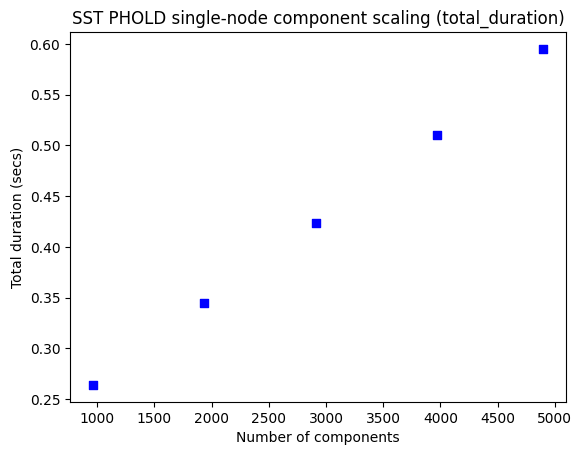

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

try:
    df = pd.read_csv(f"{baseDir}/runs/results.csv")
except FileNotFoundError as e:
    print(f'ERROR: File not found - {e.filename}')
    raise StopExecution()

fig = plt.figure()
ax = fig.add_subplot(111)

plot_value='total_duration'
ylabel = 'Total duration (secs)'

ax.scatter(x=df["Size"], y=df[plot_value], c='b', marker="s", label=f'SST 15.1.0')
ax.legend().remove()
plt.title(f'SST {benchmarkPath} single-node component scaling ({plot_value})')
plt.xlabel('Number of components')
plt.ylabel(ylabel)
plt.show()